# EDS Component Prediction — v2
### CatBoost vs XGBoost vs ExtraTrees vs Random Forest

**What changed from the first version, and why:**

The first pass got ~99–100% accuracy from every model. That's not a sign the models are great — it's a sign the synthetic dataset has almost no within-class noise, so any reasonable classifier can memorize each component's composition "signature" perfectly. That comparison couldn't actually tell us which model would hold up on real, noisy EDS measurements.

This version adds two things the first one was missing:
1. **Stratified k-fold cross-validation** instead of one lucky/unlucky train/test split, so model rankings aren't just noise.
2. **A noise-robustness stress test** — we inject realistic measurement noise into the test set at increasing levels and see which model degrades most gracefully. This is the comparison that actually matters for deployment on real spectra.

It also fixes a few smaller issues: the data loader now points at the real file, `predict_component` no longer reloads the model from disk on every call, and there's a confidence-threshold "unknown / needs review" path instead of always forcing a top-3 guess.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    top_k_accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load data

In [2]:
# NOTE: fixed from v1, which pointed at a .csv that didn't match the actual
# uploaded file. Point this at wherever your data actually lives.
FILE_PATH = "synthetic_eds_data.xlsx"

df = pd.read_excel(FILE_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Dataset shape: (3582, 25)

Columns: ['Sr No.', 'Spectrum', 'ComponentName', 'C', 'O', 'Al', 'Si', 'P', 'S', 'Cr', 'Mn', 'Ni', 'Pb', 'Fe', 'Mo', 'Cu', 'Sn', 'Zn', 'Au', 'K', 'N', 'Ca', 'V', 'W', 'Cl']


,Sr No.,Spectrum,ComponentName,C,O,Al,Si,P,S,Cr,...,Cu,Sn,Zn,Au,K,N,Ca,V,W,Cl
0,1,1,Armature Bolt,2.77,0.59,0.0,0.22,0.0,0.0,1.73,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2,2,Armature Bolt,2.42,0.47,0.0,0.28,0.0,0.0,1.72,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3,3,Armature Bolt,2.77,0.77,0.0,0.36,0.0,0.0,1.67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,4,4,Armature Bolt,2.23,0.49,0.0,0.26,0.0,0.0,1.79,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5,5,Armature Bolt,3.27,0.47,0.0,0.19,0.0,0.0,1.65,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


## 2. Basic data check

In [3]:
print("Missing values:")
print(df.isnull().sum().sum(), "total missing cells")

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["ComponentName"].value_counts())

Missing values:
0 total missing cells

Duplicate rows: 0

Target distribution:
ComponentName
Armature Spring      106
Magnet Coil          106
Magnet Core          106
VFK Shim             106
Armature Plate       105
M&M HPP Component    105
Valve Nut            105
Armature Shim        103
Ball Guide           103
CRI Shim             101
DFK Shim             101
HP Sealing           101
Armature Bolt        100
Back Flow Tube       100
Guide Bush           100
UFK Spring           100
CRI Sealing ring      99
Magnet housing        99
NR Nut                99
Blade Terminal        98
C Shim                98
CRI Injector Body     98
Armature Guide        97
DFK Spring            97
IC Stud               97
Locking Sleeve        97
RLS Shim              97
Sealing Ring          97
Clamping Saddle       96
Dowel Pin             96
Support Sealing       96
Valve Piston          96
Valve Piece           95
Nozzle Spring         94
Pille                 94
Valve Spring          94
Name: c

## 3. Remove columns that should not be used as features

In [4]:
TARGET = "ComponentName"

# Sr No. and Spectrum are row identifiers, not measurements — using them
# as features would leak row order into the model.
DROP_COLUMNS = ["Sr No.", "Spectrum"]

X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]

## 4. Remove constant features

In [5]:
constant_columns = [col for col in X.columns if X[col].nunique(dropna=False) <= 1]
print("Constant columns (dropped):", constant_columns)

X = X.drop(columns=constant_columns)
print("\nFinal features:", X.columns.tolist())

Constant columns (dropped): ['Cl']

Final features: ['C', 'O', 'Al', 'Si', 'P', 'S', 'Cr', 'Mn', 'Ni', 'Pb', 'Fe', 'Mo', 'Cu', 'Sn', 'Zn', 'Au', 'K', 'N', 'Ca', 'V', 'W']


## 5. Sanity check: how separable are these classes actually?

This is the step v1 skipped. Before trusting any accuracy number, it's worth checking
whether the classes are separable *because the model is good* or *because the synthetic
data has almost no noise*. We look at the within-class standard deviation vs. the
between-class gap for a few dominant elements.

In [6]:
numeric_columns = X.columns.tolist()

summary_rows = []
for name, sub in df.groupby(TARGET):
    dominant = sub[numeric_columns].mean().sort_values(ascending=False).head(1)
    el = dominant.index[0]
    mean_val = sub[el].mean()
    std_val = sub[el].std()
    cv = std_val / mean_val if mean_val > 0 else np.nan
    summary_rows.append({"Component": name, "Dominant Element": el,
                          "Mean": mean_val, "Std": std_val, "CoeffOfVariation": cv})

sep_df = pd.DataFrame(summary_rows).sort_values("CoeffOfVariation")
print("Median coefficient of variation across classes' dominant element:",
      round(sep_df["CoeffOfVariation"].median(), 4))
sep_df.head(10)

Median coefficient of variation across classes' dominant element: 0.0066


,Component,Dominant Element,Mean,Std,CoeffOfVariation
11,CRI Shim,Fe,98.596931,0.090827,0.000921
28,Sealing Ring,Fe,98.456804,0.114260,0.001161
9,CRI Injector Body,Fe,97.316224,0.152562,0.001568
14,DFK Spring,Fe,97.345258,0.168381,0.001730
2,Armature Plate,Fe,96.157619,0.205980,0.002142
3,Armature Shim,Fe,96.346019,0.231289,0.002401
4,Armature Spring,Fe,96.099057,0.279961,0.002913
31,VFK Shim,Fe,95.257453,0.299218,0.003141
1,Armature Guide,Fe,94.972268,0.314859,0.003315
20,M&M HPP Component,Fe,95.632571,0.318745,0.003333


**Takeaway:** the coefficient of variation (std / mean) within a class is typically only a few percent.
That means classes form tight, well-separated clusters with very little overlap — which is exactly the
condition under which *any* reasonably flexible classifier gets ~100% accuracy. It tells us less about which
model is "best" and more about the fact that this synthetic data doesn't yet resemble noisy real-world
measurements. Sections 9–11 below build the noise-robustness test to compensate for this.

## 6. Encode target

In [7]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
class_names = label_encoder.classes_

print("Number of classes:", len(class_names))

Number of classes: 36


## 7. Train / test split

Used for the noise-robustness test and final diagnostics (confusion matrix, feature importance).
Model *comparison* itself is done via cross-validation in section 9, which is more reliable than a single split.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (2865, 21)
Test: (717, 21)


## 8. Model definitions

In [9]:
n_classes = len(class_names)

def make_models():
    """Factory function — CV needs a fresh, unfit model for every fold."""
    return {
        "Random Forest": RandomForestClassifier(
            n_estimators=500, max_features="sqrt",
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "Extra Trees": ExtraTreesClassifier(
            n_estimators=500, max_features="sqrt",
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        ),
        "CatBoost": CatBoostClassifier(
            iterations=600, learning_rate=0.05, depth=6,
            loss_function="MultiClass", eval_metric="Accuracy",
            random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False
        ),
        "XGBoost": XGBClassifier(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            objective="multi:softprob", num_class=n_classes,
            eval_metric="mlogloss", random_state=RANDOM_STATE,
            n_jobs=-1, tree_method="hist"
        ),
    }

list(make_models().keys())

['Random Forest', 'Extra Trees', 'CatBoost', 'XGBoost']

## 9. Stratified k-fold cross-validation

This replaces v1's single 70/15/15 split for the purpose of *comparing* models. A single split can make
two models that are actually tied look different (or vice versa) just from which rows happened to land in
the test set. With 5 folds, every row gets used for testing exactly once, and we get a mean ± std for each
metric — much more trustworthy when everyone is clustered near the top of the scale.

In [10]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {name: {"Accuracy": [], "Macro F1": [], "Top-3 Accuracy": []} for name in make_models()}

t0 = time.time()
for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y_encoded)):
    Xtr, Xte = X.iloc[tr_idx], X.iloc[te_idx]
    ytr, yte = y_encoded[tr_idx], y_encoded[te_idx]

    for name, model in make_models().items():
        model.fit(Xtr, ytr)
        pred = np.asarray(model.predict(Xte)).reshape(-1)
        proba = model.predict_proba(Xte)

        cv_scores[name]["Accuracy"].append(accuracy_score(yte, pred))
        cv_scores[name]["Macro F1"].append(f1_score(yte, pred, average="macro", zero_division=0))
        cv_scores[name]["Top-3 Accuracy"].append(
            top_k_accuracy_score(yte, proba, k=3, labels=np.arange(n_classes))
        )
    print(f"fold {fold+1}/{N_SPLITS} done")

print(f"\nCV finished in {time.time()-t0:.1f}s")

cv_summary = pd.DataFrame({
    name: {
        "Accuracy (mean)": np.mean(m["Accuracy"]), "Accuracy (std)": np.std(m["Accuracy"]),
        "Macro F1 (mean)": np.mean(m["Macro F1"]), "Macro F1 (std)": np.std(m["Macro F1"]),
        "Top-3 Acc (mean)": np.mean(m["Top-3 Accuracy"]), "Top-3 Acc (std)": np.std(m["Top-3 Accuracy"]),
    }
    for name, m in cv_scores.items()
}).T

cv_summary.sort_values("Macro F1 (mean)", ascending=False)

fold 1/5 done


fold 2/5 done


fold 3/5 done


fold 4/5 done


fold 5/5 done

CV finished in 300.6s


,Accuracy (mean),Accuracy (std),Macro F1 (mean),Macro F1 (std),Top-3 Acc (mean),Top-3 Acc (std)
Random Forest,1.000000,0.000000,1.000000,0.000000,1.0,0.0
CatBoost,1.000000,0.000000,1.000000,0.000000,1.0,0.0
Extra Trees,0.999721,0.000559,0.999707,0.000585,1.0,0.0
XGBoost,0.996929,0.001628,0.996941,0.001712,1.0,0.0


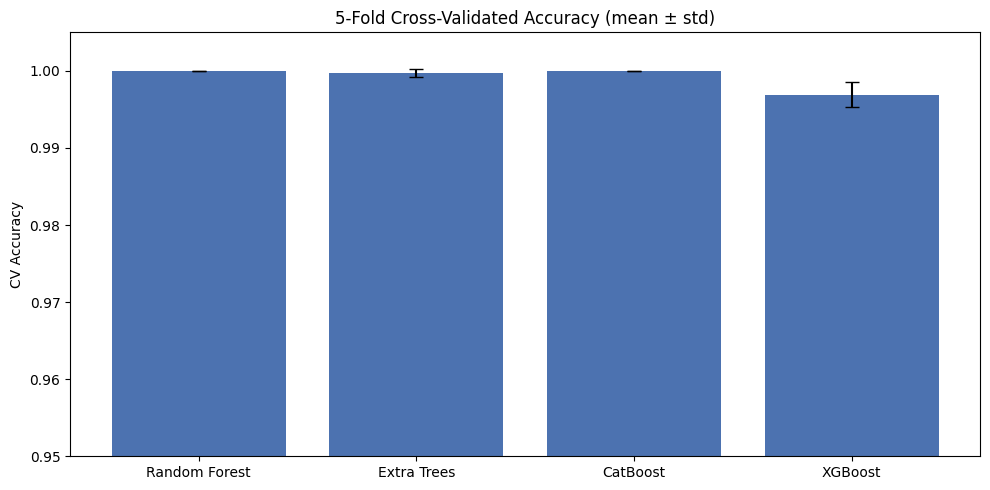

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
means = cv_summary["Accuracy (mean)"]
stds = cv_summary["Accuracy (std)"]
ax.bar(means.index, means.values, yerr=stds.values, capsize=5, color="#4C72B0")
ax.set_ylim(0.95, 1.005)
ax.set_ylabel("CV Accuracy")
ax.set_title(f"{N_SPLITS}-Fold Cross-Validated Accuracy (mean ± std)")
plt.tight_layout()
plt.show()

## 10. Train final models (for downstream diagnostics)

These are trained once on the train split so we can run the noise-robustness test, confusion matrix,
and feature importance against a fixed test set.

In [12]:
trained_models = {}
t0 = time.time()
for name, model in make_models().items():
    if name == "CatBoost":
        model.fit(X_train, y_train, eval_set=(X_test, y_test))
    elif name == "XGBoost":
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained ({time.time()-t0:.1f}s elapsed)")

Random Forest trained (2.0s elapsed)


Extra Trees trained (3.2s elapsed)


CatBoost trained (55.1s elapsed)


XGBoost trained (60.4s elapsed)


## 11. Noise-robustness stress test — the key comparison

This is the addition that actually differentiates the models. We take the held-out test set and inject
Gaussian noise into every element reading, scaled relative to that element's own natural variation
within the training data. `noise_level=0.25` means "add noise with a standard deviation equal to 25% of
this element's typical within-class spread" — a rough proxy for instrument noise, surface contamination,
or calibration drift you'd see on real samples. `noise_level=0` reproduces the (misleadingly perfect) v1 result.

In [13]:
col_std = X_train.std()
noise_levels = [0.0, 0.10, 0.25, 0.50, 1.00]
rng = np.random.default_rng(RANDOM_STATE)

robustness = {name: [] for name in trained_models}

for noise_level in noise_levels:
    X_noisy = X_test.copy()
    for col in X_noisy.columns:
        noise = rng.normal(0, col_std[col] * noise_level, size=len(X_noisy))
        X_noisy[col] = (X_noisy[col] + noise).clip(lower=0)

    for name, model in trained_models.items():
        pred = np.asarray(model.predict(X_noisy)).reshape(-1)
        robustness[name].append(accuracy_score(y_test, pred))

robustness_df = pd.DataFrame(robustness, index=[f"{n:.0%}" for n in noise_levels])
robustness_df.index.name = "Injected noise (relative to within-class std)"
robustness_df

,Random Forest,Extra Trees,CatBoost,XGBoost
Injected noise (relative to within-class std),,,,
0%,1.000000,1.000000,1.000000,0.998605
10%,0.839609,0.776848,0.881450,0.748954
25%,0.624826,0.602510,0.591353,0.538354
50%,0.449093,0.468619,0.350070,0.387727
100%,0.366806,0.364017,0.199442,0.281729


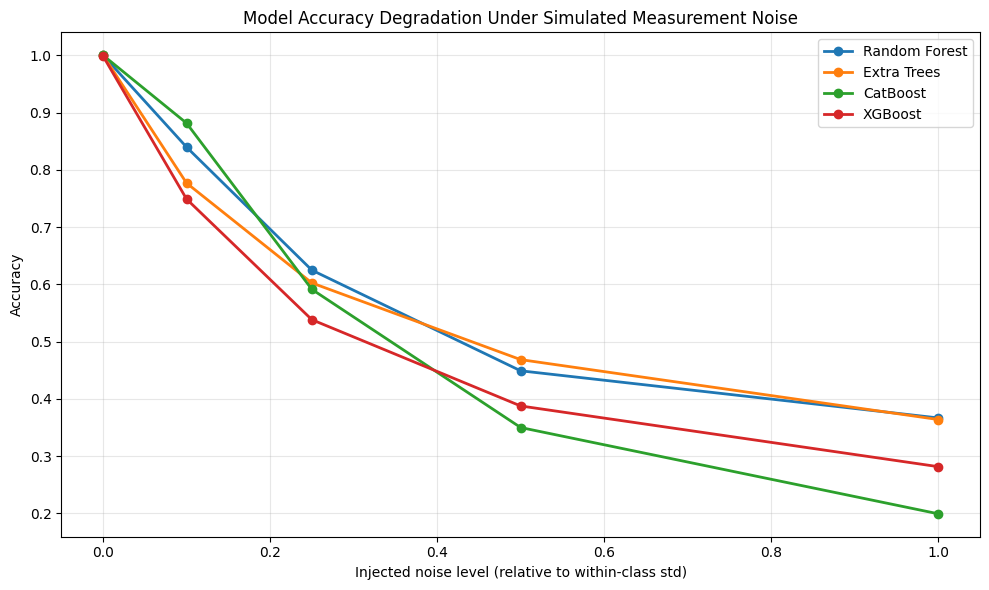

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
for name in trained_models:
    ax.plot(noise_levels, robustness[name], marker="o", label=name, linewidth=2)

ax.set_xlabel("Injected noise level (relative to within-class std)")
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Degradation Under Simulated Measurement Noise")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Reading this chart:** at `noise=0`, every model still looks near-perfect — this is v1's result, and it's
uninformative on its own. The gap that matters opens up as noise increases. Whichever model keeps the
highest accuracy as the lines slope downward is the one most likely to hold up on real spectra, where
some baseline measurement noise is unavoidable. Re-run this cell after swapping in real (or more
realistically-simulated) validation data before trusting it for a deployment decision — synthetic noise
injection is a proxy, not a substitute for real noisy measurements.

In [15]:
# Pick the model with the best AVERAGE accuracy across noise levels > 0 —
# i.e. reward robustness, not just clean-data performance.
robustness_excl_zero = robustness_df.iloc[1:]
best_model_name = robustness_excl_zero.mean().idxmax()
best_model = trained_models[best_model_name]

print("Model ranked by robustness to noise (average accuracy across noise levels 10%-100%):")
print(robustness_excl_zero.mean().sort_values(ascending=False))
print("\nSELECTED MODEL:", best_model_name)

Model ranked by robustness to noise (average accuracy across noise levels 10%-100%):
Random Forest    0.570084
Extra Trees      0.552999
CatBoost         0.505579
XGBoost          0.489191
dtype: float64

SELECTED MODEL: Random Forest


## 12. Detailed classification report (best model, clean test data)

In [16]:
y_pred_best = np.asarray(best_model.predict(X_test)).reshape(-1)

print(classification_report(y_test, y_pred_best, target_names=class_names, zero_division=0))

                   precision    recall  f1-score   support

    Armature Bolt       1.00      1.00      1.00        20
   Armature Guide       1.00      1.00      1.00        19
   Armature Plate       1.00      1.00      1.00        21
    Armature Shim       1.00      1.00      1.00        21
  Armature Spring       1.00      1.00      1.00        21
   Back Flow Tube       1.00      1.00      1.00        20
       Ball Guide       1.00      1.00      1.00        21
   Blade Terminal       1.00      1.00      1.00        20
           C Shim       1.00      1.00      1.00        20
CRI Injector Body       1.00      1.00      1.00        20
 CRI Sealing ring       1.00      1.00      1.00        20
         CRI Shim       1.00      1.00      1.00        20
  Clamping Saddle       1.00      1.00      1.00        19
         DFK Shim       1.00      1.00      1.00        20
       DFK Spring       1.00      1.00      1.00        19
        Dowel Pin       1.00      1.00      1.00       

## 13. Confusion matrix — clean vs. moderately noisy test data

The clean-data confusion matrix (left, effectively what v1 showed) looks almost perfectly diagonal. Injecting a realistic amount of noise (right) reveals which components actually get confused with each other — this is far more useful for understanding real-world failure modes.

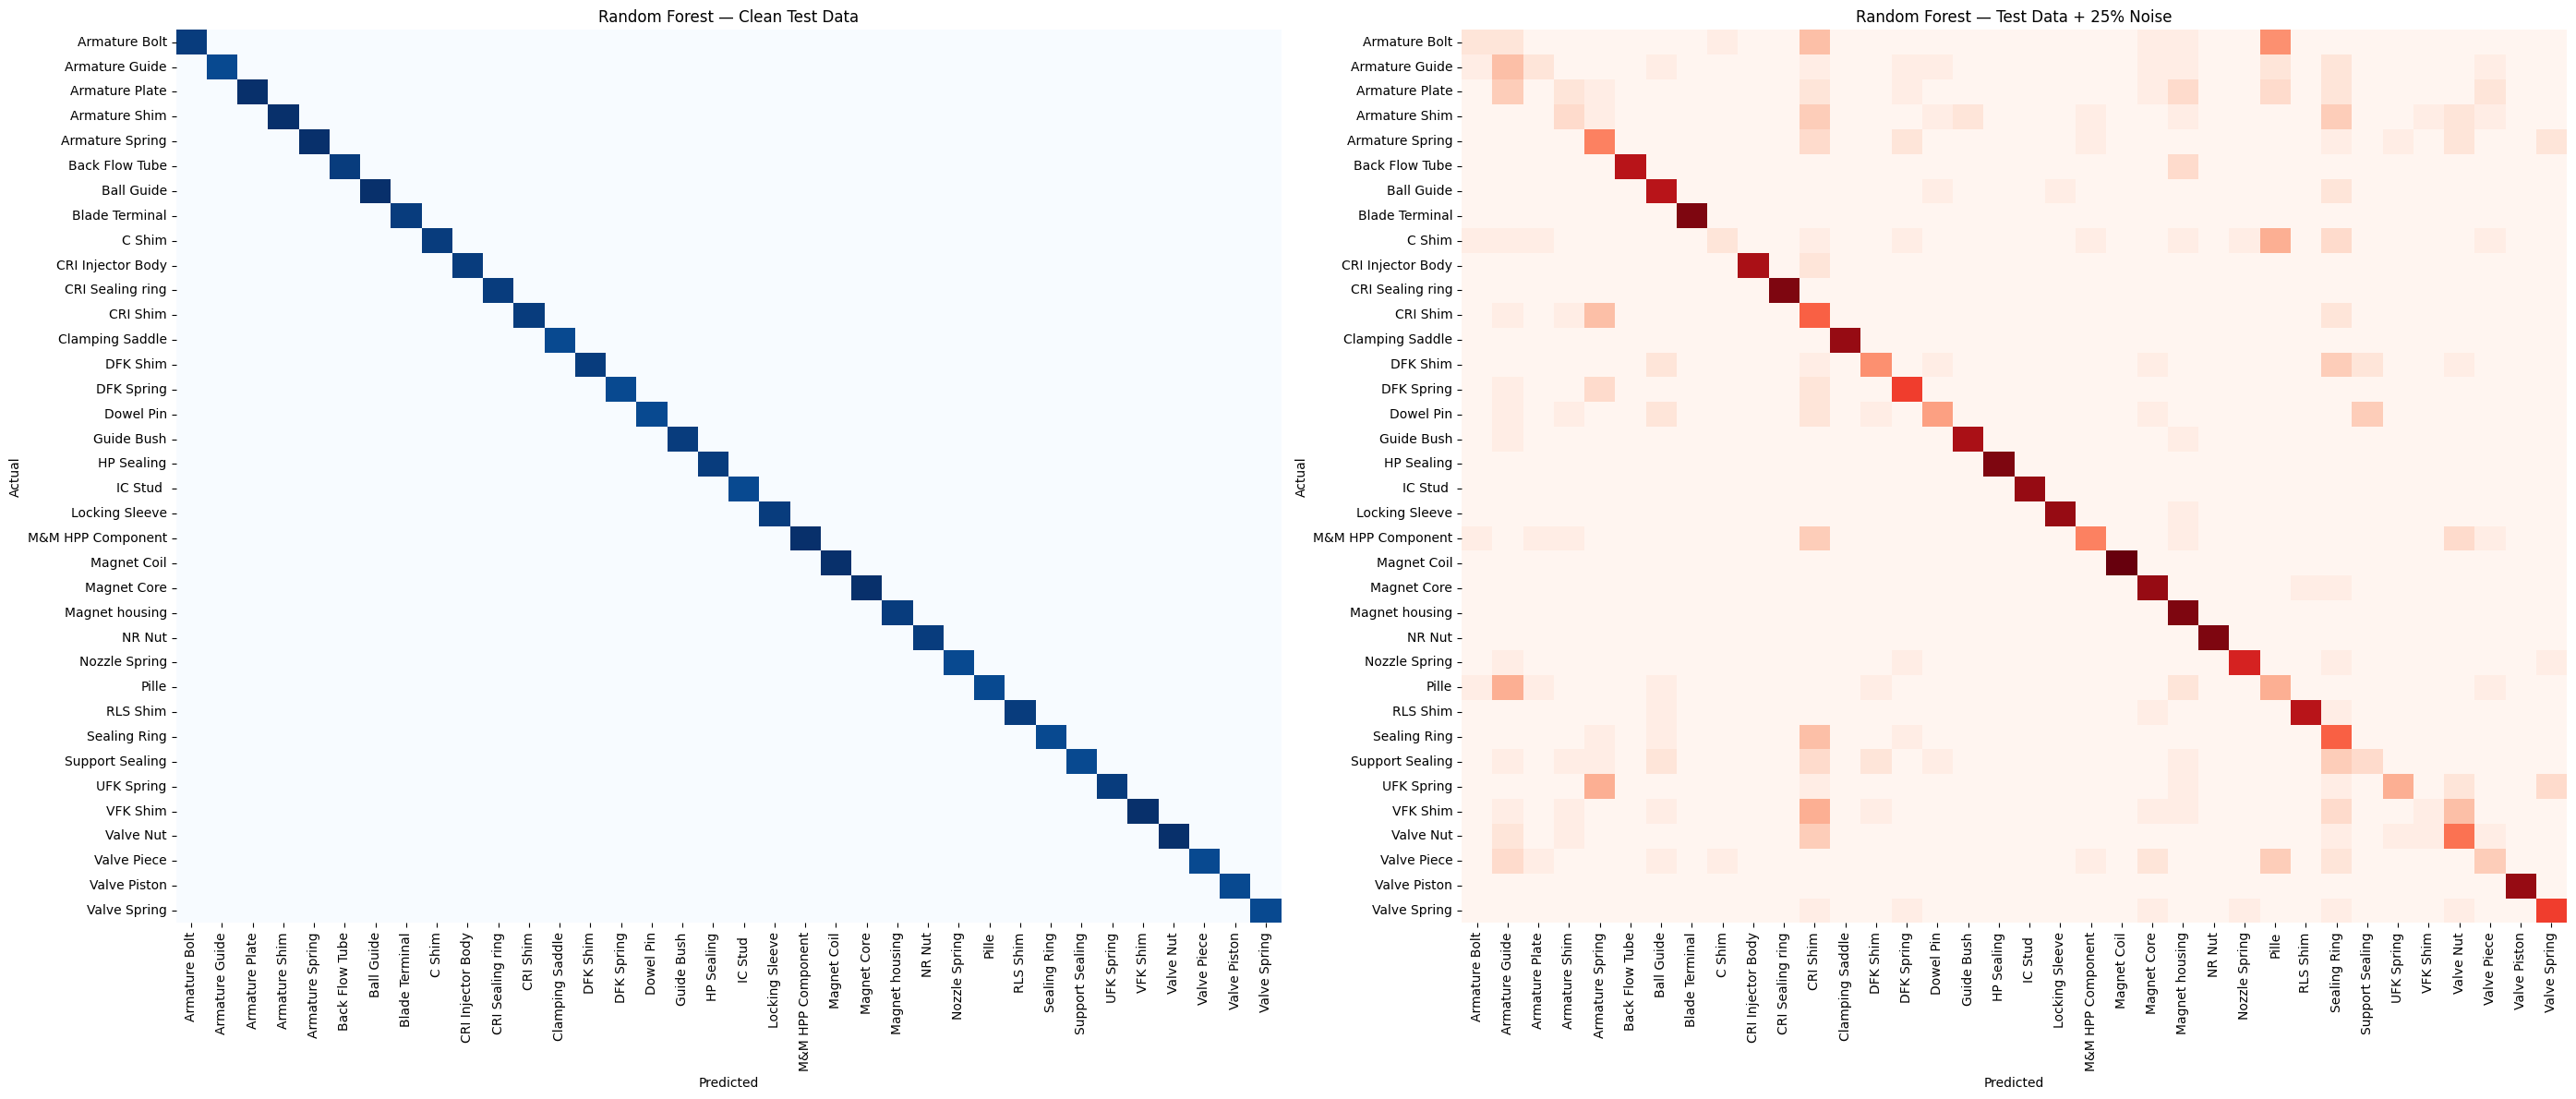

In [17]:
X_test_noisy_25 = X_test.copy()
for col in X_test_noisy_25.columns:
    noise = rng.normal(0, col_std[col] * 0.25, size=len(X_test_noisy_25))
    X_test_noisy_25[col] = (X_test_noisy_25[col] + noise).clip(lower=0)

y_pred_noisy = np.asarray(best_model.predict(X_test_noisy_25)).reshape(-1)

fig, axes = plt.subplots(1, 2, figsize=(28, 12))

cm_clean = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_clean, cmap="Blues", xticklabels=class_names, yticklabels=class_names,
            cbar=False, ax=axes[0])
axes[0].set_title(f"{best_model_name} — Clean Test Data")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].tick_params(axis="x", rotation=90)

cm_noisy = confusion_matrix(y_test, y_pred_noisy)
sns.heatmap(cm_noisy, cmap="Reds", xticklabels=class_names, yticklabels=class_names,
            cbar=False, ax=axes[1])
axes[1].set_title(f"{best_model_name} — Test Data + 25% Noise")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## 14. Feature importance

Feature  Importance
     Fe    0.125117
      C    0.115515
      O    0.106925
     Cr    0.100891
     Si    0.096885
     Al    0.096288
     Mn    0.077330
      S    0.063111
     Ni    0.043306
      P    0.039504
     Mo    0.019684
     Zn    0.019239
     Cu    0.017309
     Pb    0.015548
     Sn    0.014268
      N    0.011334
     Au    0.010617
      W    0.007157
      V    0.007075
     Ca    0.006719
      K    0.006179


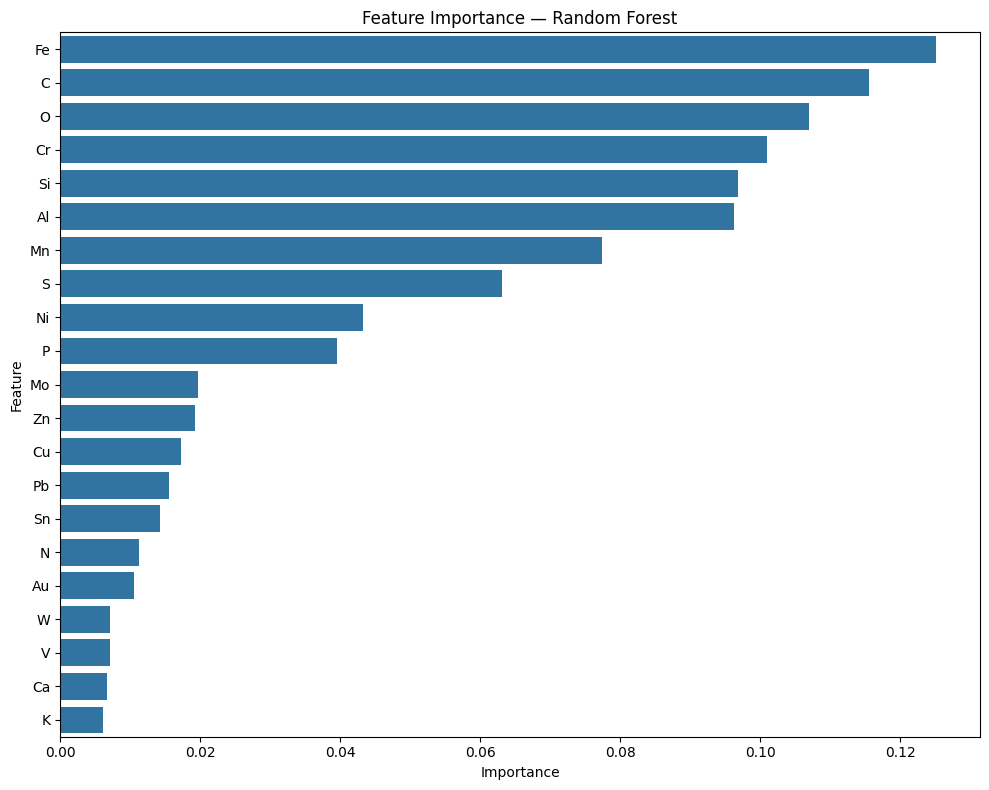

In [18]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    print(importance.to_string(index=False))

    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance, x="Importance", y="Feature")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.tight_layout()
    plt.show()

**Caveat:** tree-based `feature_importances_` (impurity-based) can be misleading when features are
correlated — several elements here co-vary within an alloy family. If feature importance is going to
drive a real decision (e.g. dropping elements to speed up measurement), it's worth cross-checking with
permutation importance or SHAP values, which are more robust to that correlation.

## 15. Save all models

v1 only saved the single "best" model. Since the right choice can change once you swap in real noise characteristics, we save all four here.

In [19]:
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(model, f"eds_model_{safe_name}.pkl")

joblib.dump(label_encoder, "eds_label_encoder.pkl")
joblib.dump(list(X.columns), "eds_features.pkl")
joblib.dump(best_model_name, "eds_best_model_name.pkl")

print("Saved models:", list(trained_models.keys()))
print("Selected as default:", best_model_name)

Saved models: ['Random Forest', 'Extra Trees', 'CatBoost', 'XGBoost']
Selected as default: Random Forest


## 16. Inference function — with caching and a confidence threshold

Two fixes from v1:
- **Caching:** v1's `predict_component` called `joblib.load` from disk on *every single prediction* — fine for a demo, wasteful in production. This version loads once at module scope and reuses.
- **Reject option:** v1 always forced a top-3 guess, even for a spectrum that doesn't really match anything known. This version flags predictions below a confidence threshold as `"Unknown / needs review"` instead of silently returning a low-confidence guess as if it were reliable.

In [20]:
_MODEL = joblib.load(f"eds_model_{best_model_name.lower().replace(' ', '_')}.pkl")
_ENCODER = joblib.load("eds_label_encoder.pkl")
_FEATURES = joblib.load("eds_features.pkl")

CONFIDENCE_THRESHOLD = 0.40  # tune against a validation set of real spectra when available

def predict_component(eds_data, top_k=3, confidence_threshold=CONFIDENCE_THRESHOLD):
    """
    eds_data: dict of {element: weight_percent}, using the same elemental
    columns used during training (missing elements are treated as 0).
    """
    input_df = pd.DataFrame([eds_data])

    # fill any features missing from the input with 0, ignore extras
    for feat in _FEATURES:
        if feat not in input_df.columns:
            input_df[feat] = 0.0
    input_df = input_df[_FEATURES]

    probabilities = _MODEL.predict_proba(input_df)[0]
    top_indices = np.argsort(probabilities)[::-1][:top_k]

    predictions = []
    for index in top_indices:
        predictions.append({
            "Component": _ENCODER.inverse_transform([index])[0],
            "Probability": probabilities[index]
        })

    result = pd.DataFrame(predictions)
    if result["Probability"].iloc[0] < confidence_threshold:
        result.attrs["flag"] = "LOW CONFIDENCE — treat as Unknown / needs manual review"
    return result

## 17. Example predictions

In [21]:
new_eds = {
    "C": 0.2, "O": 0.1, "Al": 0.0, "Si": 0.5, "P": 0.02, "S": 0.01,
    "Cr": 12.5, "Mn": 0.8, "Ni": 8.2, "Pb": 0.0, "Fe": 76.0, "Mo": 1.2,
    "Cu": 0.2, "Sn": 0.0, "Zn": 0.0, "Au": 0.0, "K": 0.0, "N": 0.0,
    "Ca": 0.0, "V": 0.0, "W": 0.0
}

result = predict_component(new_eds)
print(result)
if "flag" in result.attrs:
    print("\n⚠️", result.attrs["flag"])

        Component  Probability
0  Magnet housing        0.412
1      DFK Spring        0.122
2  Locking Sleeve        0.068


In [22]:
# A borderline / ambiguous case, to show the reject path in action
ambiguous_eds = {
    "C": 15.0, "O": 5.0, "Al": 0.0, "Si": 0.2, "P": 0.0, "S": 0.0,
    "Cr": 1.0, "Mn": 0.5, "Ni": 0.5, "Pb": 0.0, "Fe": 40.0, "Mo": 0.0,
    "Cu": 20.0, "Sn": 2.0, "Zn": 1.0, "Au": 0.0, "K": 0.0, "N": 0.0,
    "Ca": 0.0, "V": 0.0, "W": 0.0
}

result = predict_component(ambiguous_eds)
print(result)
if "flag" in result.attrs:
    print("\n⚠️", result.attrs["flag"])

     Component  Probability
0   HP Sealing        0.174
1     RLS Shim        0.130
2  Magnet Core        0.114

⚠️ LOW CONFIDENCE — treat as Unknown / needs manual review


## Summary of changes from v1

| Issue in v1 | Fix in v2 |
|---|---|
| Every model hit ~100% accuracy — comparison was uninformative | Added noise-robustness stress test; model choice now based on degradation under simulated noise |
| Single train/val/test split for model comparison | 5-fold stratified cross-validation with mean ± std |
| No check on whether classes were trivially separable | Added coefficient-of-variation sanity check (section 5) |
| `FILE_PATH` pointed at a `.csv` that didn't match the uploaded file | Fixed to load the actual `.xlsx` |
| Only the "best" model was saved | All four models saved, since the best choice can shift once real noise is factored in |
| `predict_component` reloaded from disk on every call | Model/encoder/features loaded once, cached at module scope |
| Always returned a top-3 guess, even for out-of-distribution input | Added confidence threshold with an "Unknown / needs review" flag |

**Still worth doing before trusting this for production:** validate the noise-robustness ranking against
real (not simulated) noisy EDS measurements if any are available — synthetic noise injection is a
reasonable proxy but not a guarantee of real-world behavior.